In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

In [ ]:
df = pd.read_csv('insurance.csv')
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


*Dataframe is totally clear with no missing or wrong values*

Creating a copy dataframe with numeric data only for other analytics

In [ ]:
df.smoker.unique()

array(['yes', 'no'], dtype=object)

In [ ]:
df_num = df.copy()
df_num['sex'] = (df_num['sex'] == 'male').astype(int)
df_num['smoker'] = (df_num['smoker'] == 'yes').astype(int)

In [ ]:
df_num.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
1,18,1,33.770,1,0,southeast,1725.55230
2,28,1,33.000,3,0,southeast,4449.46200
3,33,1,22.705,0,0,northwest,21984.47061
4,32,1,28.880,0,0,northwest,3866.85520


In [ ]:
print(df['region'].unique())

['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
print(df.describe())

               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.296250     0.000000   4740.287150
50%      39.000000    30.400000     1.000000   9382.033000
75%      51.000000    34.693750     2.000000  16639.912515
max      64.000000    53.130000     5.000000  63770.428010


Dataset is totally good without any defects/null/-negative values
No need to clean the dataset

# Visualizing the data

In [ ]:
for label in df.columns:
  fig = px.histogram(df,
               x=f'{label}',
               marginal='box',
               nbins=47,
               title=f'Distribution of {label}')
  fig.update_layout(bargap=0.1)
  fig.show()

**Histogram for Charges Vs Smokers**

In [ ]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='smoker',
                   color_discrete_sequence=['green', 'gray'],
                   title='Annual Medical Charges')
fig.update_layout(bargap=0.1)
fig.show()

Insight: As somking increases charges also increases

**Histogram of Charges of Male Vs Female**

In [ ]:
fig = px.histogram(df,
                   x='charges',
                   marginal='box',
                   color='sex',
                   color_discrete_sequence=['green', 'gray', 'red'],
                   title='Annual Medical Charges Vs Sex')
fig.update_layout(bargap=0.1)
fig.show()

Insight: No much difference between charges of males and females

**Histogram for Somkers Vs Sex**

In [ ]:
px.histogram(df, x='smoker', color='sex', title='Sex of Smokers')

Insigth: No much difference between Sex of smokers but male smoker area more than females

It appears that 20% of customers have reported that they smoke. Can you verify whether this matches the national average, assuming the data was collected in 2010? We can also see that smoking appears a more common habit among males. Can you verify this?

***This is important for all the featues we have becuase when we use our model of actual prediction the data will relate the population data not the data we have. So to make sure our model work well while actual pridiction we have to make sure that we train our model with current and comman/useful data.***

**Histogram of Age Vs Charges**

In [ ]:
fig = px.scatter(df,
                 x='age',
                 y='charges',
                 color='smoker',
                 opacity=0.7,
                 hover_data=['sex'],
                 title=' Distribution of Age Vs Charges')
fig.update_layout(bargap=1)
fig.update_traces(marker_size=5)
fig.show()

Insight: Charges for smokers is very high as compared to non-smokers.

We can see ***three "clusters"*** of points, each of which seems to form a line with an increasing
slope:

1. The first and the largest cluster consists primary of presumably "healthy non-smokers" who have relatively low medical charges compared to others.
2. The second cluster contains a mix of smokers and non-smokers. It's possible that these are actually two distinct but overlapping clusters: "non-smokers with medical issues".
"smokers without major medical issues".
3. The final cluster consists exclusively of smokers, presumably smokers with major medical issues that are possibly related to or worsened by smoking.

Histogram of BMI Vs Charges

In [ ]:
fig = px.scatter(df,
                 x='bmi',
                 y='charges',
                 color='smoker',
                 opacity=0.7,
                 hover_data=['sex'],
                 title=' Distribution of BMI Vs Charges')
fig.update_layout(bargap=1)
fig.update_traces(marker_size=5)
fig.show()

It appears that for non-smokers, an increase in BMI doesn't seem to be related to an increase in
medical charges. However, medical *charges* seem to be significantly higher for smokers with a BMI
greater than 30. *italicized text*

# Checking for Corelation between features

In [ ]:
df['charges'].corr(df['age']) #same as df.charges.corr(df.age)

np.float64(0.2990081933306476)

In [ ]:
df['charges'].corr(df['bmi'])

np.float64(0.19834096883362895)

In [ ]:
df['charges'].corr((df['smoker'] == 'yes').astype(int))

# another method using map
'''
##creating a new series of smoker after maping

smoker_values = {'yes':1, 'no':0}
smoker_numeric = df.smoker.map(smoker_values)

then check for correlation
df['charges'].corr(smoker_numeric)
'''

"\n##creating a new series of smoker after maping\n\nsmoker_values = {'yes':1, 'no':0}\nsmoker_numeric = df.smoker.map(smoker_values)\n\nthen check for correlation\ndf['charges'].corr(smoker_numeric)\n"

Strong correlation between smoker and charges

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.charges.corr(df.children)

np.float64(0.06799822684790478)

moderate correlation between childern and charges.

In [ ]:
df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.109272,0.042469,0.299008
bmi,0.109272,1.000000,0.012759,0.198341
children,0.042469,0.012759,1.000000,0.067998
charges,0.299008,0.198341,0.067998,1.000000


In [ ]:
df_num.corr(numeric_only=True)

,age,sex,bmi,children,smoker,charges
age,1.000000,-0.020856,0.109272,0.042469,-0.025019,0.299008
sex,-0.020856,1.000000,0.046371,0.017163,0.076185,0.057292
bmi,0.109272,0.046371,1.000000,0.012759,0.003750,0.198341
children,0.042469,0.017163,0.012759,1.000000,0.007673,0.067998
smoker,-0.025019,0.076185,0.003750,0.007673,1.000000,0.787251
charges,0.299008,0.057292,0.198341,0.067998,0.787251,1.000000


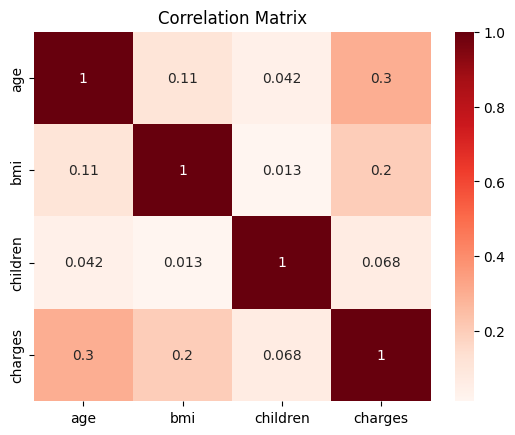

In [ ]:
sns.heatmap(df.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix')
plt.show()

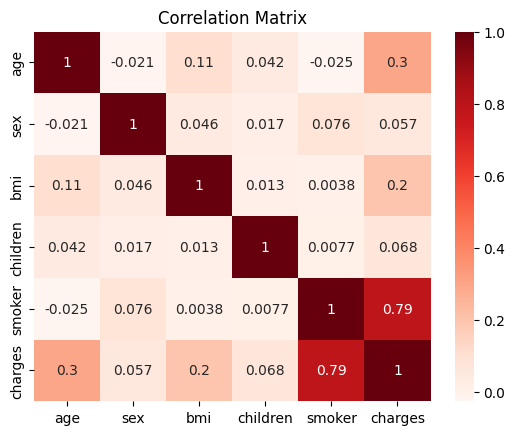

In [ ]:
sns.heatmap(df_num.corr(numeric_only=True), cmap='Reds', annot=True)
plt.title('Correlation Matrix')
plt.show()

*Correlation vs causation fallacy: Note that a high correlation cannot be used to interpret a cause-effect relationship between features. Two features X and Y can be correlated if X causes Y or if Y causes X, or if both are caused independently by some other factor Z, and the correlation will no longer hold true if one of the cause-effect relationships is broken. It's also possible that X are Y simply appear to be correlated because the sample is too small.*

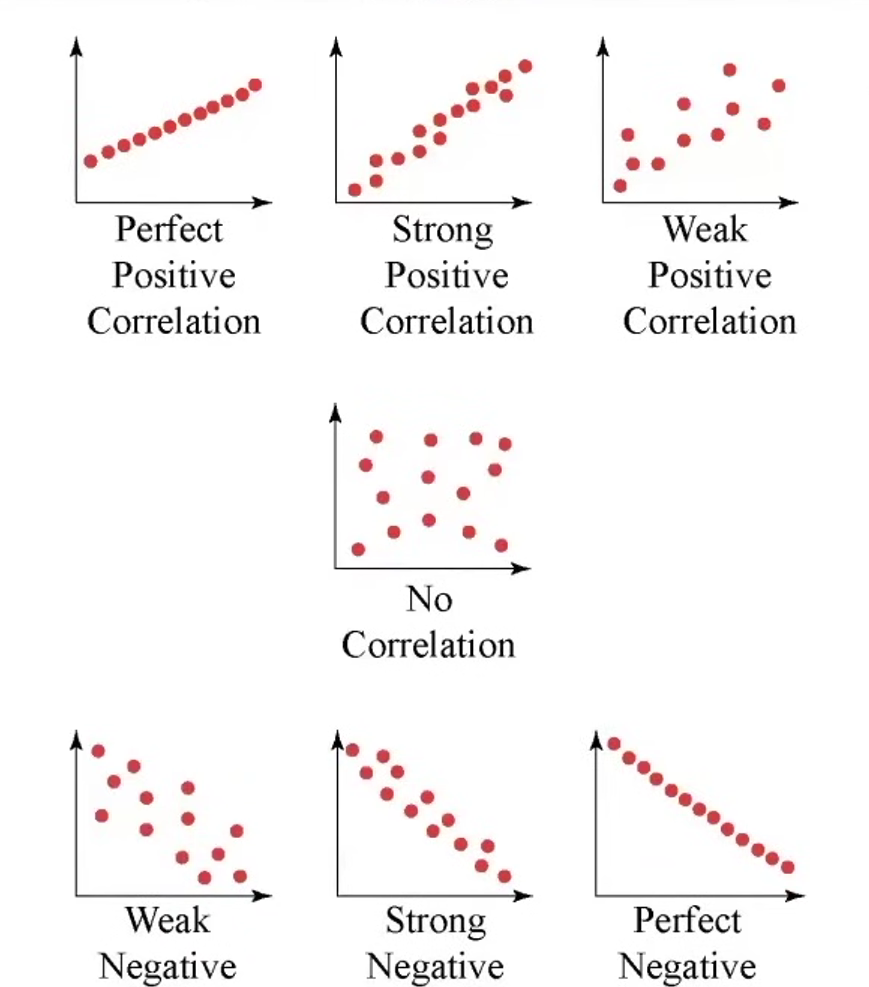

*While this may seem obvious, computers can't differentiate between correlation and causation, and decisions based on automated system can often have major consequences on society, so it's important to study why automated systems lead to a given result. Determining cause-effect relationships requires human insight.*

# Linear Regression using a Single Feature
We now know that the "smoker" and "age" columns have the strongest correlation with "charges". Let's try to find a way of estimating the value of "charges" using the value of "age" for non-smokers. First, let's create a data frame containing just the data for non-smokers.

In [ ]:
non_smoker_df = df[df.smoker == 'no']

"\nplt.scatter(x = non_smoker_df['age'], y = non_smoker_df['charges'], alpha=0.7, linewidths=0.01)\nplt.xlabel('Age')\nplt.ylabel('Charges')\nplt.grid(which='both')\nplt.show()\n"

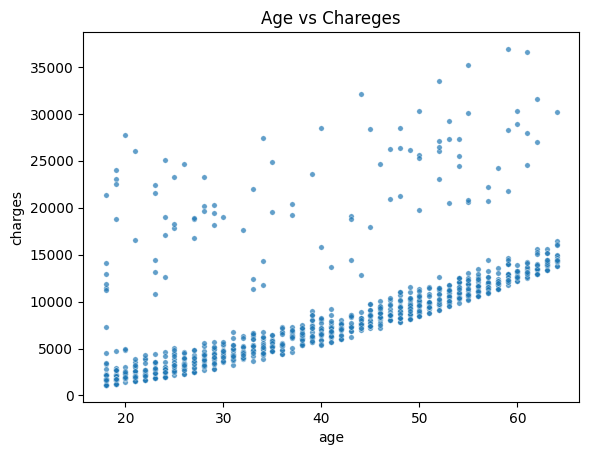

In [ ]:
plt.title('Age vs Chareges')
sns.scatterplot(data=non_smoker_df, x='age', y='charges', alpha=0.7, s=15)
'''
plt.scatter(x = non_smoker_df['age'], y = non_smoker_df['charges'], alpha=0.7, linewidths=0.01)
plt.xlabel('Age')
plt.ylabel('Charges')
plt.grid(which='both')
plt.show()
'''

Apart from a few exceptions, the points seem to form a line. We'll try and "fit" a line using this points, and use the line to predict charges for a given age. A line on the X&Y coordinates has the
following formula:

**y= wx + b**

The line is characterized two numbers: w (called "slope") and b (called "intercept").

# Model

In the above case, the x axis shows "age" and the y axis shows "charges". Thus, we're assume the following relationship between the two:

**charges = w x age + b**

We'll try determine w and b for the line that best fits the data.

. This technique is called linear regression, and we call the above equation a linear regression model, because it models the relationship between "age" and "charges" as a straight line.

. The numbers w and b are called the parameters or weights of the model.

. The values in the "age" column of the dataset are called the inputs to the model and the values in the charges column are called "targets".


Let define a helper function estimate_charges , to compute charges, given age, w and b.

In [ ]:
def estimate_charges(age, w, b):
  return w * age + b

The estimate_charges function is our first model.
Lets guss the values for w and b and use them to estimate the value of charges

In [ ]:
estimate_charges(40, 20, 4000)

4800

In [ ]:
w = 50
b = 100

In [ ]:
estimated_charges = estimate_charges(non_smoker_df['age'], w, b)
estimated_charges

,age
1,1000
2,1500
3,1750
4,1700
5,1650
...,...
1332,2700
1333,2600
1334,1000
1335,1000


**Ploting the estimate charges using a line graph for proper checking through visualizaiton.**

Compairing with actual charges

In [ ]:
non_smoker_df['charges']

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


The charges we estimated is way too different than the actual.

Ploting the estimated charges using a line graph

Text(0, 0.5, 'Estimated charges')

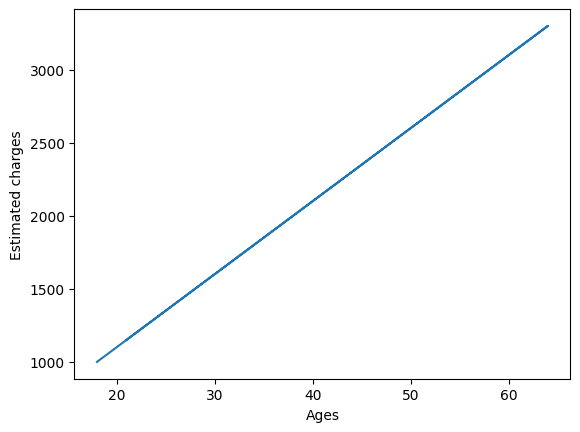

In [ ]:
plt.plot(non_smoker_df.age, estimated_charges)
plt.xlabel('Ages')
plt.ylabel('Estimated charges')

The age and charges has linear relationship as we suspected earlier

Now to check the working of our model lets overlay this with actual data.

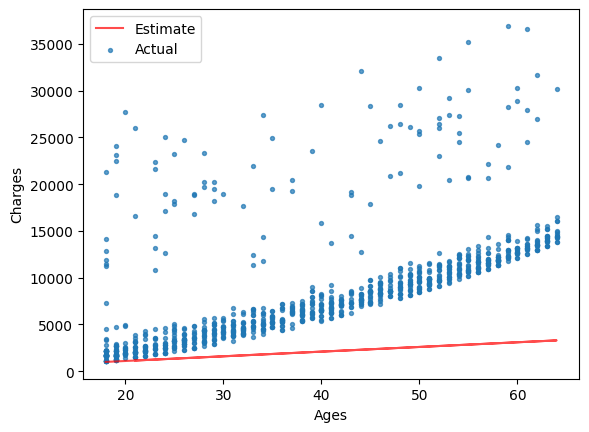

In [ ]:
plt.plot(non_smoker_df.age, estimated_charges, 'r', alpha=0.7)
plt.scatter(non_smoker_df.age, non_smoker_df.charges, s=8, alpha=0.7)
plt.xlabel('Ages')
plt.ylabel('Charges')
plt.legend(['Estimate', 'Actual'])

Clearly, the our estimates are quite poor and the line does not "fit" the data. However, we can try different values of w and b to move the line around. Let's define a helper function **try_parameters** which takes w and b as inputs and creates the above plot.

In [ ]:
def try_parameters(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges
  estimated_charges = estimate_charges(ages, w, b)
  plt.plot(ages, estimated_charges, 'r', alpha=0.7)
  plt.scatter(ages, target, s=8, alpha=0.7)
  plt.xlabel('Ages')
  plt.ylabel('Charges')
  plt.legend(['Estimate', 'Actual'])

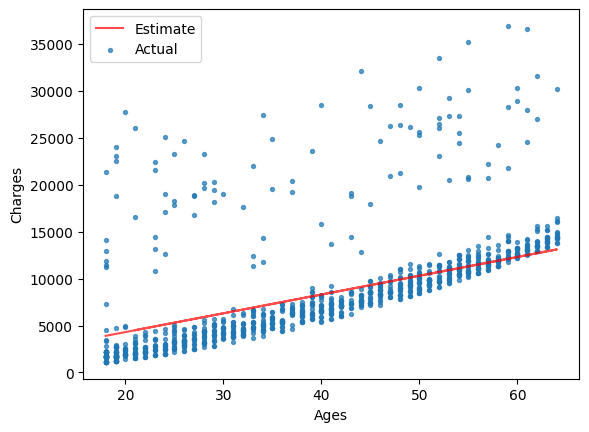

In [ ]:
try_parameters(200, 300)

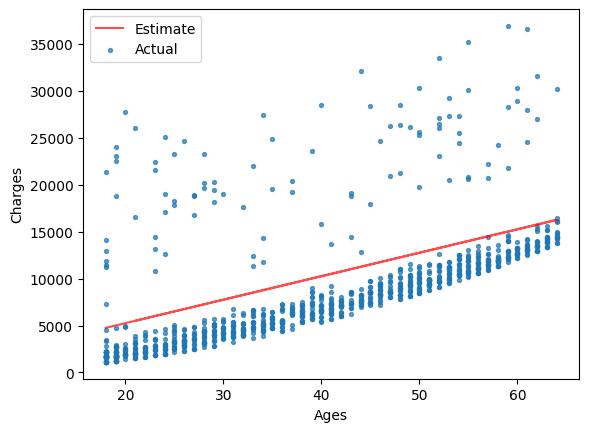

In [ ]:
try_parameters(250, 250)

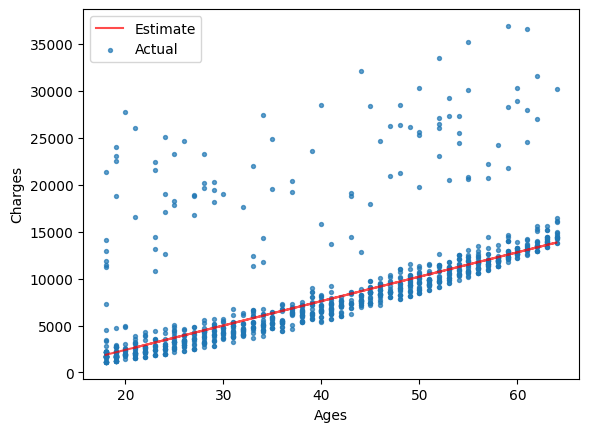

In [ ]:
try_parameters(260, -2800)

As we change the values, of w and b manually, trying to move the line visually closer to the points,
we are learning the approximate relationship between "age" and "charges".

Wouldn't it be nice if a computer could try several different values of w and b and learn the relationship between "age" and "charges"? To do this, we need to solve a couple of problems:

1. We need a way to measure numerically how well the line fits the points.
2. Once the "measure of fit" has been computed, we need a way to modify w and b to improve the the fit.

If we can solve the above problems, it should be possible for a computer to determine w and b for the best fit line, starting from a random guess.

# **Loss/Cost Function**

We can compare our model's predictions with the actual targets using the following method:

. Calculate the difference between the targets and predictions (the differenced is called the "residual")

· Square all elements of the difference to remove negative values.

· Calculate the average of the elements in the resulting matrix.

. Take the square root of the result

The result is a single number, known as the root mean squared error (RMSE). The above description can be stated mathematically as follows:

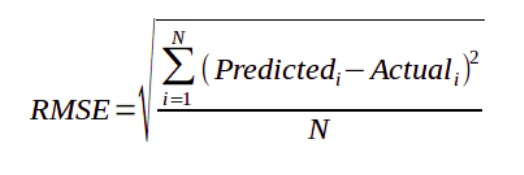


Geometrically, the residuals can be visualized as follows:


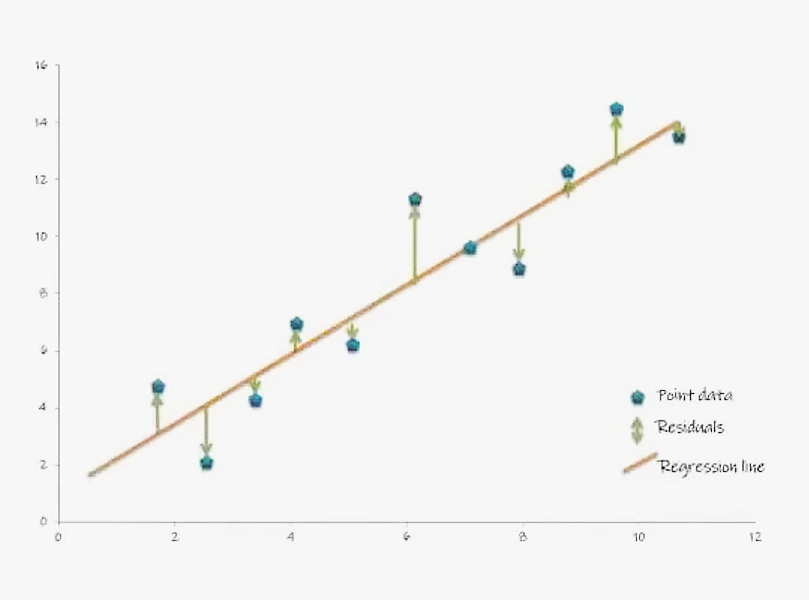

# Defining RMSE using code

In [ ]:
def rmse(targets, predictions):
  return np.sqrt(np.mean(np.square(targets - predictions)))

Computing RMSE for our model with a sample set of weights

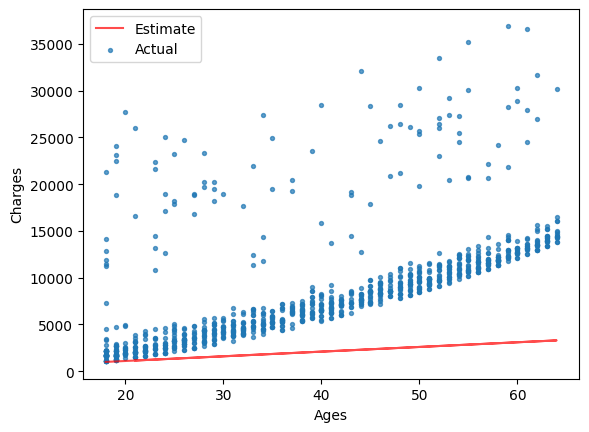

In [ ]:
w = 50
b = 100
try_parameters(w, b)

In [ ]:
targets = non_smoker_df.charges
predicted = estimate_charges(non_smoker_df.age, w, b)

In [ ]:
rmse(targets, predicted)

np.float64(8461.949562575493)

Here's how we can interpret the above number: On average, each element in the prediction differs from the actual target by $8461.

The result is called the loss because it indicates how bad the model is at predicting the target variables. It represents information loss in the model: the lower the loss, the better the model.

Let's modify the try parameters functions to also display the loss.

In [ ]:
def try_parameters(w, b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges
  pridictions = estimate_charges(ages, w, b)

  loss = rmse(targets, pridictions)
  print(f'RMSE Loss: {loss}')

  plt.scatter(ages, targets, s=8, alpha=0.7)
  plt.plot(ages, pridictions, 'r', alpha=0.7)
  plt.xlabel('Ages')
  plt.ylabel('Charges')
  plt.legend(['Actual', 'Prediction'])
  plt.show()



RMSE Loss: 8461.949562575493


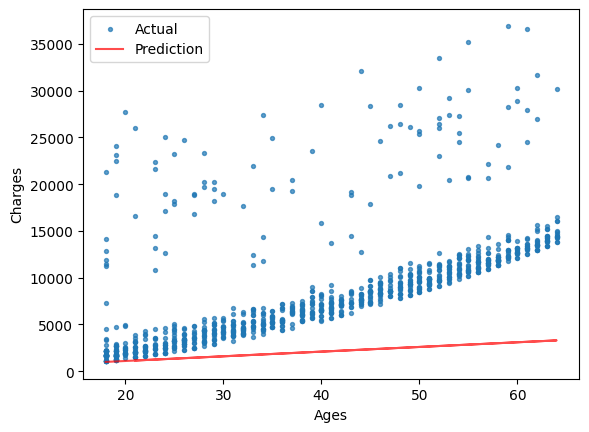

In [ ]:
try_parameters(50, 100)

We need to make the RMSE as low as possible

RMSE Loss: 4667.658904656397


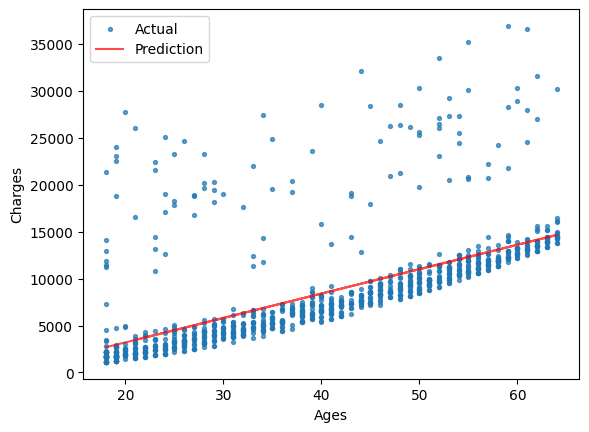

In [ ]:
try_parameters(260, -2000)

# **Optimizer**
Next, we need a strategy to modify weights w and b to reduce the loss and improve the "fit" of
the line to the data.

. Ordinary Least Squares: https://www.youtube.com/watch?v=szXbuO3bVRk (better for smaller datasets)
. Stochastic gradient descent: https://www.youtube.com/watch?v=sDv4f4s2SB8 (better for larger datasets)

Both of these have the same objective: to minimize the loss, however, while ordinary least squares directly computes the best values for w and b using matrix operations, while gradient descent
uses a iterative approach, starting with a random values of w and b and slowly improving them using derivatives.

In practice, we'll never need to implement either of the above methods by ourselves. We can use scikit-learn library to do this for us.

Using ***LinerRegression*** class from scikit-lern to find the best fit line for 'age' vs 'charges' using th *ordinary least squares* opitmization techniques.

In [ ]:
model = LinearRegression()

Next, we use the `fit` method of the model to find the best fit line for teh inputs and targets.

In [ ]:
help(model.fit)

Help on method fit in module sklearn.linear_model._base:

fit(X, y, sample_weight=None) method of sklearn.linear_model._base.LinearRegression instance
    Fit linear model.

    Parameters
    ----------
    X : {array-like, sparse matrix} of shape (n_samples, n_features)
        Training data.

    y : array-like of shape (n_samples,) or (n_samples, n_targets)
        Target values. Will be cast to X's dtype if necessary.

    sample_weight : array-like of shape (n_samples,), default=None
        Individual weights for each sample.

        .. versionadded:: 0.17
           parameter *sample_weight* support to LinearRegression.

    Returns
    -------
    self : object
        Fitted Estimator.



Note: The input `x` must be a 2-D array, so we'll need to pass a dataframe, isntead of a single column

Does fit() scale or normalize the data?

No. Absolutely not.

LinearRegression.fit():

1. ❌ does NOT scale

2. ❌ does NOT normalize

3. ❌ does NOT standardize

4. ❌ does NOT remove outliers

It assumes:

1. numeric data
2. reasonable magnitudes
3. linear relationship


  

  

  

In [ ]:
inputs = non_smoker_df[['age']] #instead of non_smoker_df['age']
targets = non_smoker_df.charges
print('input.shape: ', inputs.shape)
print('targets.shape: ', targets.shape)

input.shape:  (1064, 1)
targets.shape:  (1064,)


Fitting the data in the model to create the best line for predicting the charges.

In [ ]:
model.fit(inputs, targets)

LinearRegression()

**We can now make pridictions using the model.**

Predicting the charges for some inputs('Ages')

In [ ]:
model.predict(np.array([[23], [37], [61]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([ 4055.30443855,  7796.78921819, 14210.76312614])

Comuputing the prediction for the entire set of inputs

In [ ]:
predictions = model.predict(inputs)

In [ ]:
predictions

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [ ]:
targets

,charges
1,1725.55230
2,4449.46200
3,21984.47061
4,3866.85520
5,3756.62160
...,...
1332,11411.68500
1333,10600.54830
1334,2205.98080
1335,1629.83350


Computing RMSE loss to evluate the model.

In [ ]:
rmse(targets, predictions)

np.float64(4662.505766636395)

Our prediction is off by $4000 on average, which is not that bad considering the fact that there are several outliers.






The parameters of the model are stored in the `coef_` and `intercept_` properties.

In [ ]:
# w
model.coef_

array([267.24891283])

In [ ]:
# b
model.intercept_

np.float64(-2091.4205565650864)

To check are these values really the best one, Let's plot the graph for it.

RMSE Loss: 4662.505766636395


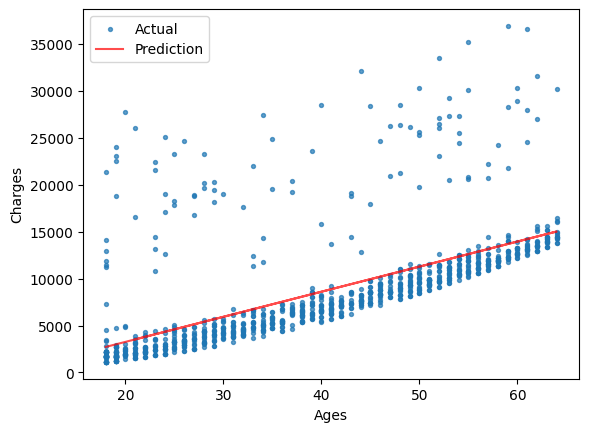

In [ ]:
try_parameters(model.coef_, model.intercept_)

# Linear Regression using Multiple Features
So far, we've used on the "age" feature to estimate "charges". Adding another feature like "bmi" is fairly straightforward. We simply assume the following relationship:

***changes = w1 x age + w2 x bmi + b***

We need to change just one line of code to include the BMI.

In [ ]:
#creating inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi']], non_smoker_df['charges']
  #as fit needs the input to be 2-D array which is already a 2-D array
  #so no need to change the input format


#create and train the model
model = LinearRegression().fit(inputs, targets)

#generating the predictions
predictions = model.predict(inputs)

#computing the loss to evaluate the model
loss = rmse(targets, predictions)
print('Loss: ', loss)

Loss:  4662.3128354612945


As you can see, adding the BMI doesn't seem to reduce the loss by much, as the BMI has a very weak correlation with charges, especially for non smokers.

In [ ]:
model.coef_, model.intercept_

(array([266.87657817,   7.07547666]), np.float64(-2293.6320906488727))

Clearly, BMI has a much lower weightage, and you can see why, it has a tiny contribution, and even that is probably accidental. This is an important thing to keep in mind: you can't find a relationship that doesn't exist, no matter what machine learning technique or optimization algorithm you apply.

Now including one more feature in the input i.e. children feature

***changes = w1 x age + w2 x bmi + w3 x children + b***

In [ ]:
#creating inputs and targets
inputs, targets = non_smoker_df[['age', 'bmi', 'children']], non_smoker_df['charges']

#fitting the data into our model
model = LinearRegression().fit(inputs, targets)

#pridicting the charges
prediction = model.predict(inputs)

#calculating the loss
loss = rmse(targets, prediction)
print('Loss: ', loss)

Loss:  4608.470405038247


Clearly, ***children*** has a lower weightage, and you can see why, it has a small contribution but greater than ***bmi***. This is because ***children*** has a little correletion with charges.

Creating a visual graph for the Line of LinearRegressoin created by our model for the there features - age, children, bmi.

In [ ]:
def try_parameters(w,b):
  ages = non_smoker_df.age
  target = non_smoker_df.charges
  estimated_charges = estimate_charges(ages, w, b)
  plt.plot(ages, estimated_charges, 'r', alpha=0.7)
  plt.scatter(ages, target, s=8, alpha=0.7)
  plt.xlabel('Ages')
  plt.ylabel('Charges')
  plt.legend(['Estimate', 'Actual'])

*Create a scatter plot to compare actual vs predicted values*

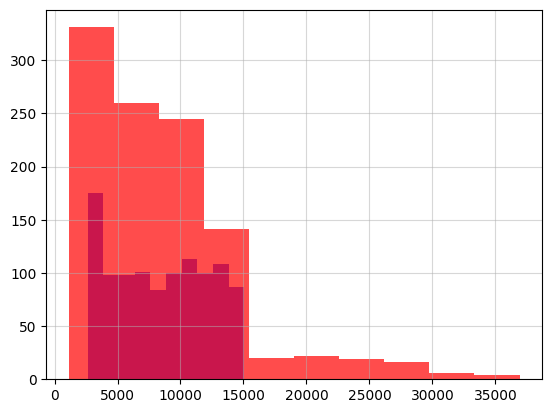

In [ ]:
plt.hist(predictions, color='blue', alpha=0.7)
plt.hist(non_smoker_df.charges, color='red', alpha=0.7)
plt.grid(alpha=.5)

#here we can see how much our prediction lies in a range of charges
#w.r.t. the actual charegs



In [ ]:

  # plt.figure(figsize=(10, 6))
  # plt.scatter(targets, prediction, alpha=0.6, color='blue', linewidth=0.5)
  # plt.show()
  # plt.scatter(prediction, targets, alpha=0.6, color='red', linewidth=0.5)
  # plt.show()

#Totally wrong this is showing nohing but the same thing with mirror image


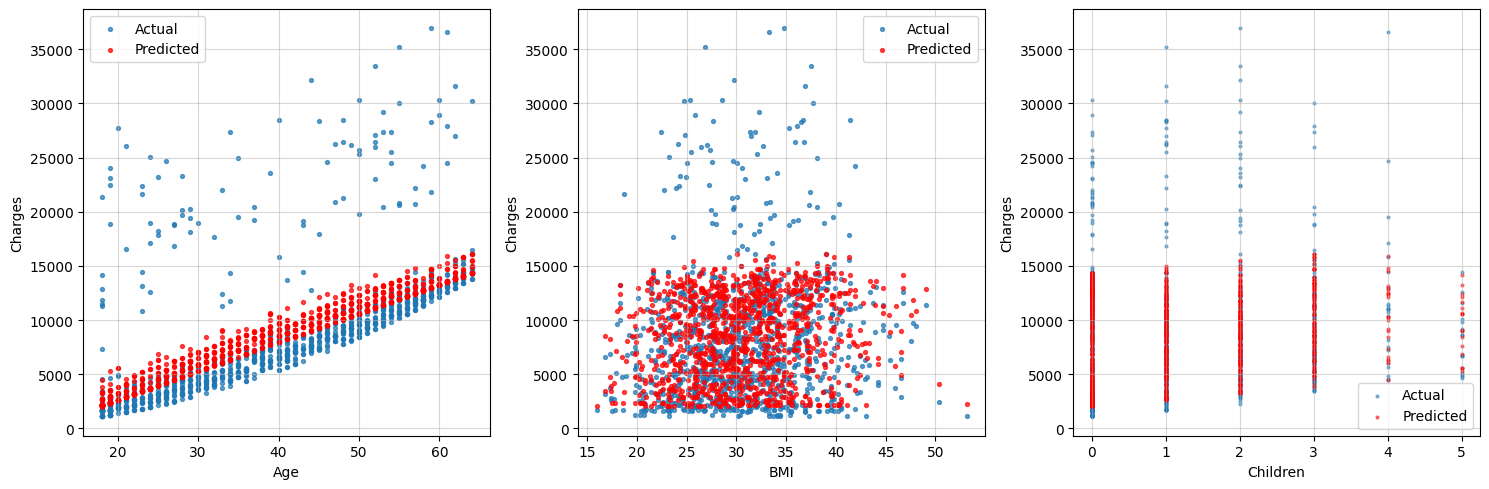

In [ ]:
# Plot predictions vs actual for AGE
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(inputs['age'], targets, s=8, alpha=0.7, label='Actual')
plt.scatter(inputs['age'], prediction, s=8, alpha=0.7, color='red', label='Predicted')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.grid(alpha=0.5)

# Plot predictions vs actual for BMI
plt.subplot(1, 3, 2)
plt.scatter(inputs['bmi'], targets, s=8, alpha=0.7, label='Actual')
plt.scatter(inputs['bmi'], prediction, s=8, alpha=0.7, color='red', label='Predicted')
plt.xlabel('BMI')
plt.ylabel('Charges')
plt.legend()
plt.grid(alpha=0.5)

# Plot predictions vs actual for CHILDREN
plt.subplot(1, 3, 3)
plt.scatter(inputs['children'], targets, s=4, alpha=0.5, label='Actual')
plt.scatter(inputs['children'], prediction, s=4, alpha=0.5, color='red', label='Predicted')
plt.xlabel('Children')
plt.ylabel('Charges')
plt.legend()
plt.grid(alpha=0.5)

plt.tight_layout()
plt.show()


# Smoker Data
Now the same with smokers only (this will help to practice all the concepts learnt till now)

In [ ]:
smoker_df = df[df['smoker']=='yes']

In [ ]:
#smoker_df['smoker'] = (smoker_df['smoker']=='yes').astype(int)
smoker_df.loc[:, 'smoker'] = (smoker_df['smoker'] == 'yes').astype(int)
smoker_df.loc[:, 'sex'] = (smoker_df['sex']=='male').astype(int)

In [ ]:
smoker_df

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,southwest,16884.92400
11,62,0,26.290,0,1,southeast,27808.72510
14,27,1,42.130,0,1,southeast,39611.75770
19,30,1,35.300,0,1,southwest,36837.46700
23,34,0,31.920,1,1,northeast,37701.87680
...,...,...,...,...,...,...,...
1313,19,0,34.700,2,1,southwest,36397.57600
1314,30,0,23.655,3,1,northwest,18765.87545
1321,62,1,26.695,0,1,northeast,28101.33305
1323,42,0,40.370,2,1,southeast,43896.37630


In [ ]:
print(smoker_df.age.max())
print(smoker_df.age.min())

64
18


# Creating model for Smoker

Using only age as a input in our model

Checking for correlation

In [ ]:
smoker_df.corr(numeric_only=True)

,age,bmi,children,charges
age,1.000000,0.059674,0.081183,0.368224
bmi,0.059674,1.000000,-0.012619,0.806481
children,0.081183,-0.012619,1.000000,0.035945
charges,0.368224,0.806481,0.035945,1.000000


In [ ]:
def try_parameters(w, b, pridictions):
  ages = smoker_df.age
  target = smoker_df.charges

  loss = rmse(targets, pridictions)
  print(f'RMSE Loss: {loss}')

  plt.scatter(ages, targets, s=8, alpha=0.7)
  plt.plot(ages, pridictions, 'r', alpha=0.7)
  plt.xlabel('Ages')
  plt.ylabel('Charges')
  plt.legend(['Actual', 'Prediction'])
  plt.show()


In [ ]:
inputs, targets = smoker_df[['age']], smoker_df['charges']

In [ ]:
model = LinearRegression().fit(inputs, targets)

In [ ]:
prediction = model.predict(inputs)

In [ ]:
rmse(prediction, targets)


np.float64(10711.00334810241)

In [ ]:
model.coef_, model.intercept_

(array([305.23760211]), np.float64(20294.128126915966))

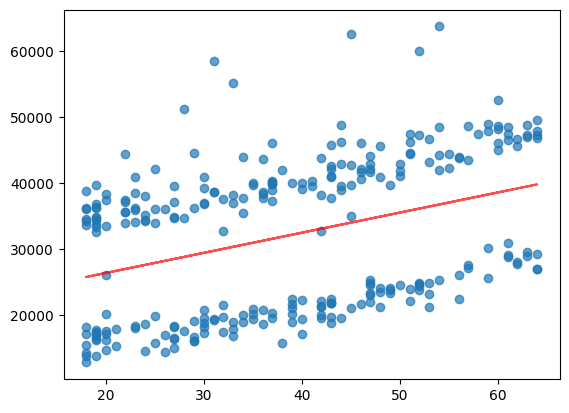

In [ ]:
plt.plot(smoker_df.age, prediction, alpha=0.7, color='red')
plt.scatter(smoker_df.age, targets, alpha=0.7)

The prediction line is too far from the concentrated data is because the correlation of age and charges is very less.

Now making model using the BMI feature

In [ ]:
inputs, targets = smoker_df[['bmi']], smoker_df.charges

In [ ]:
model = LinearRegression().fit(inputs, targets)

In [ ]:
prediction = model.predict(inputs)

In [ ]:
model.coef_, model.intercept_

(array([1473.1062547]), np.float64(-13186.57632276294))

In [ ]:
rmse(targets, prediction)

np.float64(6811.59740830196)

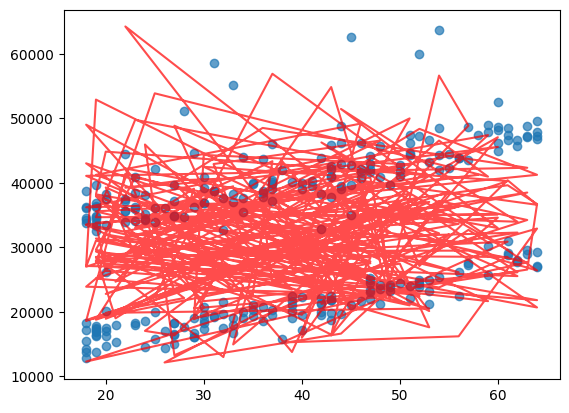

In [ ]:
plt.plot(smoker_df.age, prediction, alpha=0.7, color='red')
plt.scatter(smoker_df.age, targets, alpha=0.7)

So we can see there is no much difference in the RMSE over age and BMI. Now let's see how our model works when we combine both age and BMI in our model.

In [ ]:
inputs, targets = smoker_df[['age','bmi']], smoker_df.charges

In [ ]:
model = LinearRegression().fit(inputs, targets)

In [ ]:
prediction = model.predict(inputs)

In [ ]:
model.coef_, model.intercept_

(array([ 266.29222371, 1438.09098289]), np.float64(-22367.449727751275))

In [ ]:
rmse(targets, prediction)

np.float64(5722.782238884455)

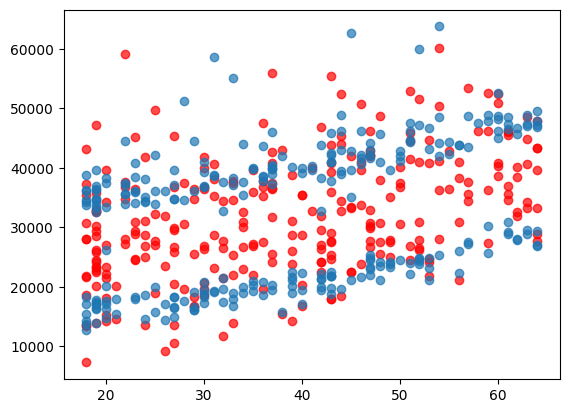

In [ ]:
plt.scatter(smoker_df.age, prediction, alpha=0.7, color='red')
plt.scatter(smoker_df.age, targets, alpha=0.7)

So using the BMI and age both together in our model has significantly reduced the rmse and thus let's combine some more in features in our model so that we can get a much better model than this for better predictions.

So let's add a children feature in our model

In [ ]:
inputs, targets = smoker_df[['age','bmi', 'children']], smoker_df.charges

In [ ]:
model = LinearRegression().fit(inputs, targets)

In [ ]:
prediction = model.predict(inputs)

In [ ]:
model.coef_, model.intercept_

(array([ 264.93316919, 1438.72926245,  198.88027911]),
 np.float64(-22556.088196491593))

In [ ]:
rmse(targets, prediction)

np.float64(5718.202480524154)

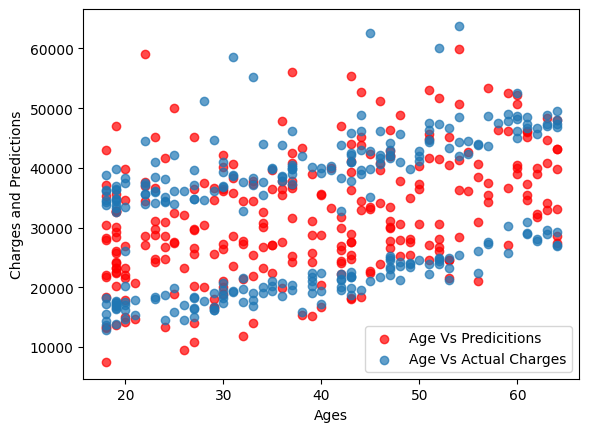

In [ ]:
plt.scatter(smoker_df.age, prediction, alpha=0.7, color='red', label='Age Vs Predicitions')
plt.scatter(smoker_df.age, targets, alpha=0.7, label='Age Vs Actual Charges')
plt.xlabel('Ages')
plt.ylabel('Charges and Predictions')
plt.legend()

So the least amount of RMSE I can get is about 5718 and that's much better than simply adding a age or BMI and If you see too solely age over BMI it is better but not good enough than non smoker data where we get the RMSE about 4700 or something.

As we can see in the above chart that the prediction is mostly concentrated between the two clusters of the actual charges and this is due to the linear regression because it creates a single line which is an average of actually target label which we want to predict and so that's why the prediction is between the two clusters.
If we see according to RMSE it is pretty good but for someone like high end engineer and high end model which is required for actual real time predict it is not good enough. Both of the predictions we get from non smoker data and the smoker data are pretty far from the actual British target and we need to improve it more and more so that we can count on this model for a prediction

# Using Categorical Features for Machine Learning
So far we've been using only numeric columns, since we can only perform computations with numbers. If we could use categorical columns like "smoker", we can train a single model for the entire dataset.

To use the categorical columns, we simply need to convert them to numbers. There are three common techniques for doing this:

1. If a categorical column has just two categories (it's called a *binary category*), then we can replace their values with 0 and 1.
2. If a categorical column has more than 2 categories, we can perform ***one-hot encoding*** i.e. create a new column for each category with 1s and 0s.
3. If the categories have a natural order (e.g. cold, neutral, warm, hot), then they can be converted to numbers (e.g. 1, 2, 3, 4) preserving the order. These are called **ordinals**.

We have already converted the smoker and sex into 0 and 1 and now let's convert region feature using the *one-hot endcoding encoding* so that we can also use that feature in our model It could be a feature which can help us to improve our model.

So using one hotel encoding we're gonna create four new features for each regions which are 'southwest', 'southeast', 'northwest', 'northeast' etc As 0 and 1  for each and use them in our model for prediction.

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df['sex'] = (df['sex']=='female').astype(int)
df['smoker'] = (df['smoker']=='yes').astype(int)

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,1,southwest,16884.92400
1,18,0,33.770,1,0,southeast,1725.55230
2,28,0,33.000,3,0,southeast,4449.46200
3,33,0,22.705,0,0,northwest,21984.47061
4,32,0,28.880,0,0,northwest,3866.85520


Using **sklearn.preprocessing** module for one-hot encoding for the region feature to create four different features which we will add to the data frame.

In [ ]:
ohenc = preprocessing.OneHotEncoder()
ohenc.fit(df[['region']])
ohenc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [ ]:
one_hot = ohenc.transform(df[['region']]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]])

In [ ]:
df[['northeast', 'northwest', 'southeast', 'southwest']] = one_hot
df.drop('region', axis = 1, inplace = True)

Now including the region feature having the values of the region separately in the data frame for our model.

In [ ]:
df.head()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
0,19,1,27.900,0,1,16884.92400,0.0,0.0,0.0,1.0
1,18,0,33.770,1,0,1725.55230,0.0,0.0,1.0,0.0
2,28,0,33.000,3,0,4449.46200,0.0,0.0,1.0,0.0
3,33,0,22.705,0,0,21984.47061,0.0,1.0,0.0,0.0
4,32,0,28.880,0,0,3866.85520,0.0,1.0,0.0,0.0


In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'northeast',
       'northwest', 'southeast', 'southwest'],
      dtype='object')

In [ ]:
df.corr()

,age,sex,bmi,children,smoker,charges,northeast,northwest,southeast,southwest
age,1.000000,0.020856,0.109272,0.042469,-0.025019,0.299008,0.002475,-0.000407,-0.011642,0.010016
sex,0.020856,1.000000,-0.046371,-0.017163,-0.076185,-0.057292,0.002425,0.011156,-0.017117,0.004184
bmi,0.109272,-0.046371,1.000000,0.012759,0.003750,0.198341,-0.138156,-0.135996,0.270025,-0.006205
children,0.042469,-0.017163,0.012759,1.000000,0.007673,0.067998,-0.022808,0.024806,-0.023066,0.021914
smoker,-0.025019,-0.076185,0.003750,0.007673,1.000000,0.787251,0.002811,-0.036945,0.068498,-0.036945
charges,0.299008,-0.057292,0.198341,0.067998,0.787251,1.000000,0.006349,-0.039905,0.073982,-0.043210
northeast,0.002475,0.002425,-0.138156,-0.022808,0.002811,0.006349,1.000000,-0.320177,-0.345561,-0.320177
northwest,-0.000407,0.011156,-0.135996,0.024806,-0.036945,-0.039905,-0.320177,1.000000,-0.346265,-0.320829
southeast,-0.011642,-0.017117,0.270025,-0.023066,0.068498,0.073982,-0.345561,-0.346265,1.000000,-0.346265
southwest,0.010016,0.004184,-0.006205,0.021914,-0.036945,-0.043210,-0.320177,-0.320829,-0.346265,1.000000


In [ ]:
df[['age', 'sex', 'bmi', 'children', 'smoker', 'charges']].corr()['charges'].drop('charges')
#first we checkt the check the correlation w.r.t. charges and then drop the charges column which is not necessary

,charges
age,0.299008
sex,-0.057292
bmi,0.198341
children,0.067998
smoker,0.787251


**charges = w1 x age + W2 x bmi + W3 x charges + W4 x smoker + w5 x sex + w6 x northeast + w7 x northwest + w8 x southeast + w9 x southwest + b**

In [ ]:
inputs, targets = df[['age','bmi', 'children', 'smoker', 'sex', 'northeast', 'northwest', 'southeast', 'southwest']], df.charges

In [ ]:
model = LinearRegression().fit(inputs, targets)

In [ ]:
prediction = model.predict(inputs)

In [ ]:
prediction

array([25293.7130284 ,  3448.60283431,  6706.9884907 , ...,
        4149.13248568,  1246.58493898, 37085.62326757])

In [ ]:
model.coef_, model.intercept_

(array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
          131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
         -373.04175627]),
 np.float64(-12656.862170590564))

In [ ]:
rmse(targets, prediction)

np.float64(6041.6796511744515)

In [ ]:
len(prediction)

1338

In [ ]:
len(df.age)

1338

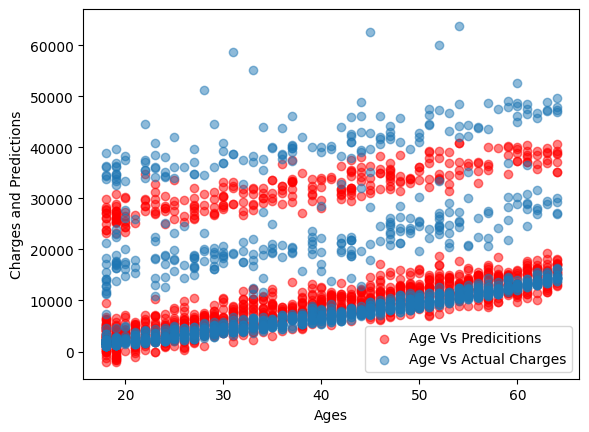

In [ ]:
plt.scatter(df.age, prediction, alpha=0.5, color='red', label='Age Vs Predicitions')
plt.scatter(df.age, targets, alpha=0.5, label='Age Vs Actual Charges')
plt.xlabel('Ages')
plt.ylabel('Charges and Predictions')
plt.legend()

Are two separate linear regression models one for smoker and one for non-smoker better than a linear single linear regression model? Why or why not? We should try to see it and justify our answer with the data.

In [ ]:
model.predict([[23, 30, 2, 1, 0, 0, 1, 0, 0 ]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but LinearRegression was fitted with feature names



array([28460.21851391])

In [ ]:
model.coef_

array([  256.85635254,   339.19345361,   475.50054515, 23848.53454191,
         131.3143594 ,   587.00923503,   234.0453356 ,  -448.01281436,
        -373.04175627])

In [ ]:
model.intercept_

np.float64(-12656.862170590564)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'northeast',
       'northwest', 'southeast', 'southwest'],
      dtype='object')

In [ ]:
weights_df = pd.DataFrame({
    'features' : np.append(['age', 'sex', 'bmi', 'children', 'smoker', 'northeast','northwest', 'southeast', 'southwest'], 'intercept'),
    'weight' : np.append(model.coef_, model.intercept_)
})
weights_df

,features,weight
0,age,256.856353
1,sex,339.193454
2,bmi,475.500545
3,children,23848.534542
4,smoker,131.314359
5,northeast,587.009235
6,northwest,234.045336
7,southeast,-448.012814
8,southwest,-373.041756
9,intercept,-12656.862171


While it seems like BMI and the "northeast" have a higher weight than age, keep in mind that the
range of values for BMI is limited (15 to 40) and the "northeast" column only takes the values 0 and
1.

Because different columns have different ranges, we run into two issues:

1. We can't compare the weights of different column to identify which features are important
2. A column with a larger range of inputs may disproportionately affect the loss and dominate the
optimization process.

For this reason, it's common practice to scale (or standardize) the values in numeric column by
subtracting the mean and dividing by the standard deviation.

Standardization:

x -u
z= *-

with mean:

u =

1
N

N
Σ(χ;)
i=1

and standard deviation:

0 =

1

1
N

N
Σ(χi -μ)2
i=1

We can apply scaling using the StandardScaler class from scikit-learn .

In [ ]:
numeric_cols = ['age', 'bmi', 'children']
scaler = StandardScaler()
scaler.fit(df[numeric_cols])

StandardScaler()

In [ ]:
scaler.mean_

array([39.20702541, 30.66339686,  1.09491779])

In [ ]:
scaler.var_

array([197.25385199,  37.16008997,   1.45212664])

In [ ]:
scaled_inputs = scaler.transform(df[numeric_cols])
scaled_inputs

array([[-1.43876426, -0.45332   , -0.90861367],
       [-1.50996545,  0.5096211 , -0.07876719],
       [-0.79795355,  0.38330685,  1.58092576],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367],
       [-1.29636188, -0.79781341, -0.90861367],
       [ 1.55168573, -0.26138796, -0.90861367]])

These can now be combined with the categorical data

In [ ]:
cat_cols = ['smoker', 'sex', 'northeast', 'northwest', 'southeast', 'southwest']
categorical_data = df[cat_cols].values

In [ ]:
inputs = np.concatenate((scaled_inputs, categorical_data), axis=1)
targets = df.charges

#creating and training the model
model = LinearRegression().fit(inputs, targets)

#generating predicitons
predictions = model.predict(inputs)

#compute loss to evalue the model
loss = rmse(targets, predictions)
print('Loss = ', loss)

Loss =  6041.6796511744515


In [ ]:
inputs

array([[-1.43876426, -0.45332   , -0.90861367, ...,  0.        ,
         0.        ,  1.        ],
       [-1.50996545,  0.5096211 , -0.07876719, ...,  0.        ,
         1.        ,  0.        ],
       [-0.79795355,  0.38330685,  1.58092576, ...,  0.        ,
         1.        ,  0.        ],
       ...,
       [-1.50996545,  1.0148781 , -0.90861367, ...,  0.        ,
         1.        ,  0.        ],
       [-1.29636188, -0.79781341, -0.90861367, ...,  0.        ,
         0.        ,  1.        ],
       [ 1.55168573, -0.26138796, -0.90861367, ...,  1.        ,
         0.        ,  0.        ]])

Now we can compare the weights in teh formuls.

*charges = w1 x age + W2 x bmi + W3 x charges + W4 x smoker + w5 x sex + w6 x northeast + w7 x northwest + w8 x southeast + w9 x southwest + b*

In [ ]:
weights_df = pd.DataFrame({
    'features': np.append(numeric_cols + cat_cols, 'intercept'),
    'weight': np.append(model.coef_, model.intercept_)
})
weights_df.sort_values('weight', ascending=False)

,features,weight
3,smoker,23848.534542
9,intercept,8335.168856
0,age,3607.472736
1,bmi,2067.691966
5,northeast,587.009235
2,children,572.998210
6,northwest,234.045336
4,sex,131.314359
8,southwest,-373.041756
7,southeast,-448.012814


This is the End of the problem's solution. We have successfully created a Machine Learning program which predicts the Annual Charges of a person depending on it data.